Import Libraries

In [ ]:
import pandas as pd
import re

In [ ]:
f = open(r"/content/chat.txt", encoding='utf-8')


In [ ]:
data = f.read()

In [ ]:
print(data)

1/1/25, 8:02 PM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
1/5/25, 1:10 PM - Ashi: HELLO EVERYONE
1/5/25, 1:10 PM - Ashi: Plz apne songs batao
1/5/25, 1:10 PM - Ashi: Mujhko event wale ko bhejna hai
1/5/25, 1:13 PM - ShauryaRake07🦉😎: Hm bhojpuri pe dance krunga
1/5/25, 1:15 PM - Ashi: Gaana likh kr bhejo jldi
1/5/25, 1:15 PM - Subhi: Ek group danceee please
1/5/25, 1:16 PM - Ashi: Plz gaane batado
1/5/25, 1:16 PM - Subhi: Sab batao bhailog group performance ka
1/5/25, 1:16 PM - Ashi: Bataooooo jldiii
1/5/25, 1:16 PM - Sunny: Tum log song decide kar lo
1/5/25, 1:16 PM - Sunny: And video share kar dena
1/5/25, 1:17 PM - Sunny: We will practice
1/5/25, 1:17 PM - Sunny: Iss baar pakka
1/5/25, 1:17 PM - Ashi: Wait sending
1/5/25, 1:18 PM - Mahi: https://www.instagram.com/reel/DDj-QyrTk5i/?igsh=eXVsZGJiZTNueDhh

you guys wanna do this?
1/5/25, 1:18 PM - Mahi: this song
1/5/25, 1:20 PM - Sunny: Cool
1/5/25, 1:20 PM -

In [ ]:
pattern = r"(\d{1,2}/\d{1,2}/\d{2,4}),\s(\d{1,2}:\d{2})\s?(AM|PM|am|pm)?\s-\s([^:]+):\s(.*)"


In [ ]:
matches = re.findall(pattern, data)

In [ ]:
# Extract dates and messages from the matches
dates = [match[0:3] for match in matches] # Extract date and time components
messages = [match[3:] for match in matches] # Extract sender and message

In [ ]:
message_data = []
for i in range(len(dates)):
    message_data.append({
        'user_messages': messages[i][1],  # Get the message text
        'message_date': dates[i][0] + ', ' + dates[i][1] + ' ' + (dates[i][2] if dates[i][2] else '')  # Combine date and time
    })

# Create the DataFrame
df = pd.DataFrame(message_data)

# Convert message_date to datetime, handling potential errors
df['message_date'] = pd.to_datetime(df['message_date'], format='%m/%d/%y, %I:%M %p', errors='coerce')

# Rename column
df.rename(columns={'message_date': 'date'}, inplace=True)

df.head()

,user_messages,date
0,HELLO EVERYONE,2025-01-05 13:10:00
1,Plz apne songs batao,2025-01-05 13:10:00
2,Mujhko event wale ko bhejna hai,2025-01-05 13:10:00
3,Hm bhojpuri pe dance krunga,2025-01-05 13:13:00
4,Gaana likh kr bhejo jldi,2025-01-05 13:15:00


In [ ]:
df.shape

(1050, 2)

In [ ]:
#separate users and messages

users=[]
messages = []
# Iterate through the 'user_messages' column
for message in df['user_messages']: # Changed from df['message'] to df['user_messages']
  entry = re.split('([\w\W]+?):\s', message)
  if entry[1:]:
    users.append(entry[1])
    messages.append(entry[2])
  else:
    users.append('group_notification')
    messages.append(entry[0])

df['users'] = users
df['message'] = messages # Creates the 'message' column

In [ ]:
df.head()

,user_messages,date,users,message
0,HELLO EVERYONE,2025-01-05 13:10:00,group_notification,HELLO EVERYONE
1,Plz apne songs batao,2025-01-05 13:10:00,group_notification,Plz apne songs batao
2,Mujhko event wale ko bhejna hai,2025-01-05 13:10:00,group_notification,Mujhko event wale ko bhejna hai
3,Hm bhojpuri pe dance krunga,2025-01-05 13:13:00,group_notification,Hm bhojpuri pe dance krunga
4,Gaana likh kr bhejo jldi,2025-01-05 13:15:00,group_notification,Gaana likh kr bhejo jldi


In [ ]:
df['year'] = df['date'].dt.year

In [ ]:
df.head()

,user_messages,date,users,message,year
0,HELLO EVERYONE,2025-01-05 13:10:00,group_notification,HELLO EVERYONE,2025
1,Plz apne songs batao,2025-01-05 13:10:00,group_notification,Plz apne songs batao,2025
2,Mujhko event wale ko bhejna hai,2025-01-05 13:10:00,group_notification,Mujhko event wale ko bhejna hai,2025
3,Hm bhojpuri pe dance krunga,2025-01-05 13:13:00,group_notification,Hm bhojpuri pe dance krunga,2025
4,Gaana likh kr bhejo jldi,2025-01-05 13:15:00,group_notification,Gaana likh kr bhejo jldi,2025


In [ ]:
df['month'] = df['date'].dt.month_name()

In [ ]:
df['day'] = df['date'].dt.day

In [ ]:
df['hour'] = df['date'].dt.hour

In [ ]:
df['minute'] = df['date'].dt.minute

In [ ]:
df.head()

,user_messages,date,users,message,year,month,day,hour,minute
0,HELLO EVERYONE,2025-01-05 13:10:00,group_notification,HELLO EVERYONE,2025,January,5,13,10
1,Plz apne songs batao,2025-01-05 13:10:00,group_notification,Plz apne songs batao,2025,January,5,13,10
2,Mujhko event wale ko bhejna hai,2025-01-05 13:10:00,group_notification,Mujhko event wale ko bhejna hai,2025,January,5,13,10
3,Hm bhojpuri pe dance krunga,2025-01-05 13:13:00,group_notification,Hm bhojpuri pe dance krunga,2025,January,5,13,13
4,Gaana likh kr bhejo jldi,2025-01-05 13:15:00,group_notification,Gaana likh kr bhejo jldi,2025,January,5,13,15


In [ ]:
df[df['users'] == 'Sid2'].shape # Changed 'user' to 'users'


(0, 9)

In [ ]:
words=[]
for message in df['message']:
   words.extend(message.split())

In [ ]:
len(words)

2728

In [ ]:
df[df['message'] == '<Media omitted>/n']

,user_messages,date,users,message,year,month,day,hour,minute


In [ ]:
!pip install urlextract # Install the missing urlextract package
from urlextract import URLExtract
extractor = URLExtract()
urls = extractor.find_urls("Let's www.gmail.com URL stackoverflow as www.stackoverflow.com www.facebook.com")
print(urls)

['www.gmail.com', 'www.stackoverflow.com', 'www.facebook.com']


In [ ]:
links=[]
for messsage in df['message']:
  links.extend(extractor.find_urls(messsage))

In [ ]:
len(links)

21

In [ ]:
x = df['users'].value_counts().head()

In [ ]:
import matplotlib.pyplot as plt
name = x.index
count = x.values


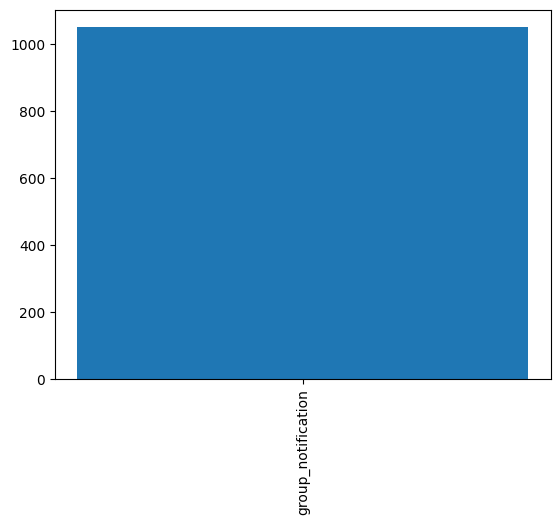

In [ ]:
plt.bar(name,count)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
round((df['users'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={'index':'name','users':'percent'})

,percent,count
0,group_notification,100.0


In [ ]:
temp = df[df['users'] != 'group_notification']
temp = temp[temp['message'] != '<Media omitted>\n']

In [ ]:
f = open('stop_hinglish.txt', 'r')
stop_words = f.read()
print(stop_words)

.
..
...
?
-
--
1
2
3
4
5
6
7
8
9
0
a
aadi
aaj
aap
aapne
aata
aati
aaya
aaye
ab
abbe
abbey
abe
abhi
able
about
above
accha
according
accordingly
acha
achcha
across
actually
after
afterwards
again
against
agar
ain
aint
ain't
aisa
aise
aisi
alag
all
allow
allows
almost
alone
along
already
also
although
always
am
among
amongst
an
and
andar
another
any
anybody
anyhow
anyone
anything
anyway
anyways
anywhere
ap
apan
apart
apna
apnaa
apne
apni
appear
are
aren
arent
aren't
around
arre
as
aside
ask
asking
at
aur
avum
aya
aye
baad
baar
bad
bahut
bana
banae
banai
banao
banaya
banaye
banayi
banda
bande
bandi
bane
bani
bas
bata
batao
bc
be
became
because
become
becomes
becoming
been
before
beforehand
behind
being
below
beside
besides
best
better
between
beyond
bhai
bheetar
bhi
bhitar
bht
bilkul
bohot
bol
bola
bole
boli
bolo
bolta
bolte
bolti
both
brief
bro
btw
but
by
came
can
cannot
cant
can't
cause
causes
certain
certainly
chahiye
chaiye
chal
chalega
chhaiye
clearly
c'mon
com
come
comes
could
coul

In [ ]:
words = []

for message in temp['message']:
  for word in messsage.lower().split():
    if word not in stop_words:
      words.append(word)



In [ ]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

""


In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 12.1 MB/s eta 0:00:00


In [ ]:
import emoji
# Get the emoji dictionary directly using emoji.EMOJI_DATA
emojis = []
for message in df['message']:
  emojis.extend([c for c in message if c in emoji.EMOJI_DATA]) # Use emoji.EMOJI_DATA to get the emoji data

In [ ]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,❤,104
1,😍,47
2,😂,45
3,🧿,32
4,😘,24
5,💖,12
6,💕,12
7,🏻,11
8,🤣,11
9,🫶,10


In [ ]:
df['month_num'] = df['date'].dt.month

In [ ]:
timeline = df.groupby(['year', 'month_num', 'month']).count()['message'].reset_index()

In [ ]:
timeline

,year,month_num,month,message
0,2025,1,January,141
1,2025,2,February,580
2,2025,3,March,196
3,2025,4,April,133


In [ ]:
time = []
for i in range(timeline.shape[0]):
  time.append(timeline['month'][i] + '-' + str(timeline['year'][i]))


In [ ]:
timeline['time'] = time

In [ ]:
timeline

,year,month_num,month,message,time
0,2025,1,January,141,January-2025
1,2025,2,February,580,February-2025
2,2025,3,March,196,March-2025
3,2025,4,April,133,April-2025


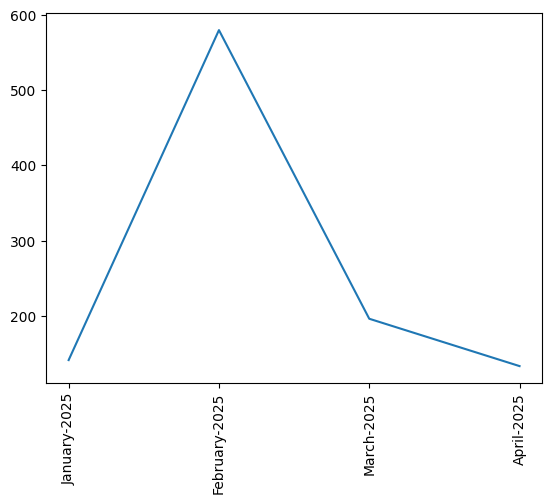

In [ ]:
plt.plot(timeline['time'], timeline['message'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
df['only_date'] = df['date'].dt.date

In [ ]:
daily_timeline = df.groupby('only_date').count()['message'].reset_index()

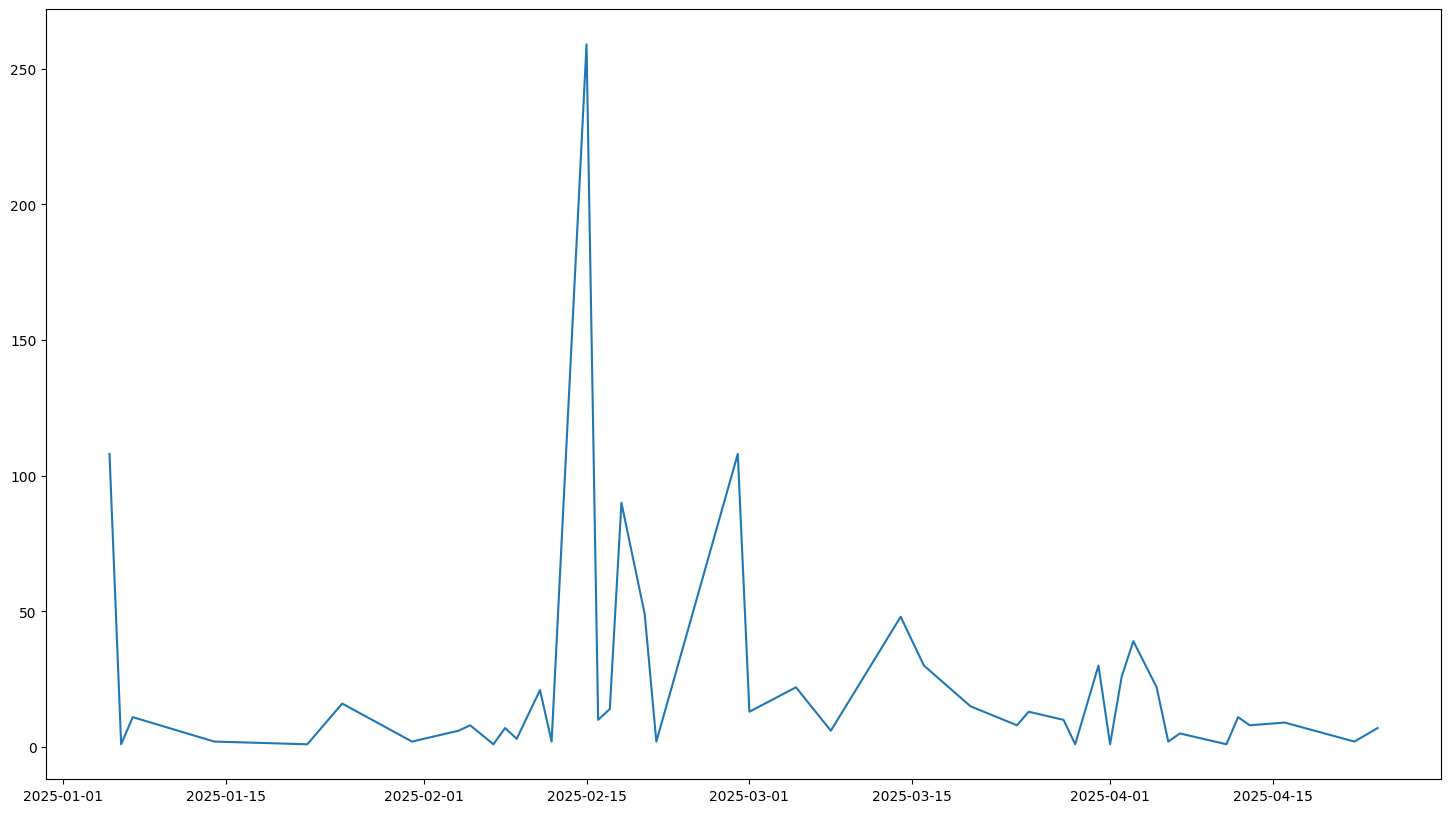

In [ ]:
plt.figure(figsize=(18,10))
plt.plot(daily_timeline['only_date'], daily_timeline['message'])

In [ ]:
df['day_name'] = df['date'].dt.day_name()

In [ ]:
df['day_name'].value_counts()

,count
day_name,
Saturday,335
Friday,172
Sunday,161
Tuesday,146
Thursday,110
Wednesday,68
Monday,58


In [ ]:
df.head()

,user_messages,date,users,message,year,month,day,hour,minute,month_num,only_date,day_name
0,HELLO EVERYONE,2025-01-05 13:10:00,group_notification,HELLO EVERYONE,2025,January,5,13,10,1,2025-01-05,Sunday
1,Plz apne songs batao,2025-01-05 13:10:00,group_notification,Plz apne songs batao,2025,January,5,13,10,1,2025-01-05,Sunday
2,Mujhko event wale ko bhejna hai,2025-01-05 13:10:00,group_notification,Mujhko event wale ko bhejna hai,2025,January,5,13,10,1,2025-01-05,Sunday
3,Hm bhojpuri pe dance krunga,2025-01-05 13:13:00,group_notification,Hm bhojpuri pe dance krunga,2025,January,5,13,13,1,2025-01-05,Sunday
4,Gaana likh kr bhejo jldi,2025-01-05 13:15:00,group_notification,Gaana likh kr bhejo jldi,2025,January,5,13,15,1,2025-01-05,Sunday


In [ ]:
period = []
for hour in df[['day_name', 'hour']]['hour']:
  if hour == 23:
    period.append(str(hour) + "-" + str('00'))
  elif hour == 0:
    period.append(str('00') + "-" + str(hour + 1))
  else:
    period.append(str(hour) + "-" + str(hour + 1))



In [ ]:
df['period'] = period

In [ ]:
df.sample(5)

,user_messages,date,users,message,year,month,day,hour,minute,month_num,only_date,day_name,period
809,Soo truee,2025-03-14 20:14:00,group_notification,Soo truee,2025,March,14,20,14,3,2025-03-14,Friday,20-21
541,<Media omitted>,2025-02-18 12:32:00,group_notification,<Media omitted>,2025,February,18,12,32,2,2025-02-18,Tuesday,12-13
506,<Media omitted>,2025-02-18 12:32:00,group_notification,<Media omitted>,2025,February,18,12,32,2,2025-02-18,Tuesday,12-13
184,WHEN ?,2025-02-11 23:40:00,group_notification,WHEN ?,2025,February,11,23,40,2,2025-02-11,Tuesday,23-00
972,<Media omitted>,2025-04-03 20:25:00,group_notification,<Media omitted>,2025,April,3,20,25,4,2025-04-03,Thursday,20-21


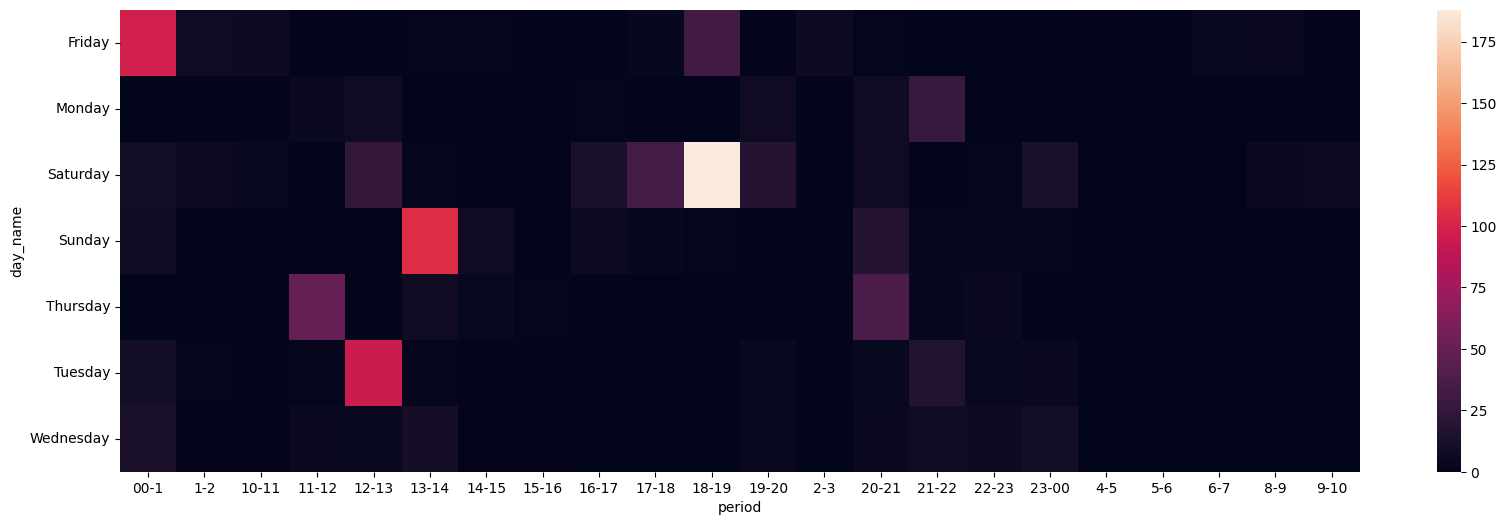

In [ ]:
import seaborn as sns
plt.figure(figsize=(20,6))
sns.heatmap(df.pivot_table(index='day_name', columns='period', values='message', aggfunc='count').fillna(0))
plt.yticks(rotation='horizontal')
plt.show()